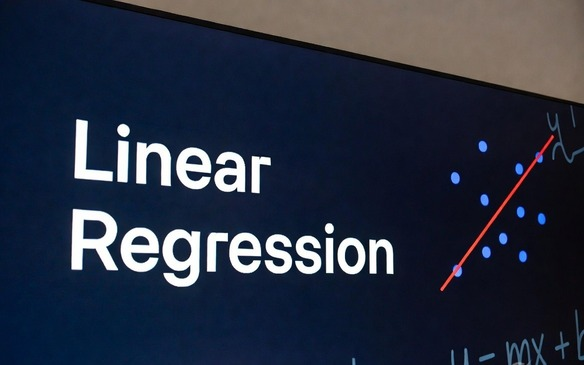

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score)

In [5]:
df = pd.read_csv("googleplaystore_cleaned.csv")
df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Sentiment_Polarity,Sentiment_Subjectivity,Translated_Review
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19.0,10000,Free,0.0,Everyone,Art & Design,2018-01-07,1.0.0,4.0.3 and up,NaN,NaN,NaN
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14.0,500000,Free,0.0,Everyone,Art & Design;Pretend Play,2018-01-15,2.0.0,4.0.3 and up,0.152652,0.64154,44.0
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7,5000000,Free,0.0,Everyone,Art & Design,2018-08-01,1.2.4,4.0.3 and up,NaN,NaN,NaN
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25.0,50000000,Free,0.0,Teen,Art & Design,2018-06-08,Varies with device,4.2 and up,NaN,NaN,NaN
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8,100000,Free,0.0,Everyone,Art & Design;Creativity,2018-06-20,1.1,4.4 and up,NaN,NaN,NaN


In [6]:
features = ["Category", "Reviews", "Size", "Installs", "Type", "Price", "Content Rating",
    "Genres", "Sentiment_Polarity", "Sentiment_Subjectivity"]

target = "Rating"

df = df[features + [target]]

In [7]:
# dropping missing values

df = df.dropna()

In [8]:
X = df[features]
y = df[target]

In [9]:
# Numerical & Categorical

num_cols = ["Reviews", "Size", "Installs", "Price", "Sentiment_Polarity", "Sentiment_Subjectivity"]

cat_cols = ["Category", "Type", "Content Rating", "Genres"]

In [10]:
# Preprocessing

preprocessor = ColumnTransformer( transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ])

In [11]:
# Pipeline

model = Pipeline([("preprocessor", preprocessor), ("regressor", LinearRegression())])

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20, random_state=42)

In [13]:
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Reviews', 'Size',
                                                   'Installs', 'Price',
                                                   'Sentiment_Polarity',
                                                   'Sentiment_Subjectivity']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Category', 'Type',
                                                   'Content Rating',
                                                   'Genres'])])),
                ('regressor', LinearRegression())])

In [14]:
# Predict

y_pred = model.predict(X_test)

In [18]:
# Metrics

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

print(f"\nModel Accuracy (R²): {r2*100:.2f}%")

MAE  : 0.2400
MSE  : 0.0933
RMSE : 0.3054
R²   : -0.0017

Model Accuracy (R²): -0.17%


In [16]:
# Actual vs Predicted

results = pd.DataFrame({
    "Actual Rating": y_test.values,
    "Predicted Rating": y_pred
})

print("\nSample Predictions:")
print(results.head(10))


Sample Predictions:
   Actual Rating  Predicted Rating
0            4.4          4.277749
1            4.0          4.112143
2            4.3          4.102085
3            3.8          3.942599
4            4.2          4.240839
5            4.3          3.950531
6            4.5          4.394161
7            4.4          3.931497
8            4.7          4.529202
9            4.0          4.255516


# Prediction Summary

## Objective

The objective of this project was to predict the rating of an Android application using app-related features such as Category, Reviews, Size, Installs, Type, Price, Content Rating, Genres, Sentiment Polarity, and Sentiment Subjectivity.

## Data Preparation

* Selected relevant numerical and categorical features.
* Applied One-Hot Encoding to categorical variables.
* Applied Standard Scaling to numerical features.
* Split the dataset into 80% training and 20% testing data.

## Model Used

* Linear Regression

## Evaluation Metrics

MAE: 0.2400

MSE: 0.0933

RMSE: 0.3054

R² Score: -0.0017

## Key Findings

* The model achieved a low prediction error with an RMSE of 0.3054.
* However, the R² score was negative, indicating that the model was unable to explain the variation in app ratings effectively.
* Most app ratings were concentrated between 4.0 and 4.5 stars, causing the model to predict values close to the average rating.
* The available features were not strong predictors of app ratings.

## Business Insight

App ratings appear to depend heavily on factors not available in the dataset, such as user experience, application quality, bugs, performance, customer support, and overall user satisfaction.

## Conclusion

Although Linear Regression successfully generated predictions, the selected features were insufficient to accurately explain app rating behavior. Future improvements may include richer user-review features, sentiment analysis, app quality metrics, and advanced machine learning models.
